In [2]:
# create network using igraph

import json

# first, read the data
with open(file="../data/mastodon.trump.json") as f:
    data = json.load(f)


In [10]:
# data has in_reply_to_account_id which is the edge we will use to create the directed graph, and for each record, we have two sublist which are called ancestors and descendants. We will go thought these to create the nodes.

# create a directed graph
g = ig.Graph(directed=True)

# create a dictionary to store the node id and the account username
id_to_username = {}
node_count = 0
for record in data:
    node = record["account"]["id"]
    g.add_vertex(name=node)
    id_to_username[record["account"]["id"]] = record["account"]["username"]
    if record["in_reply_to_account_id"] is not None:
        g.add_vertex(name=record["in_reply_to_account_id"])
        g.add_edge(node, record["in_reply_to_account_id"])
    if record.get("ancestors", None) and len(record["ancestors"]) > 0:
        for account in record["ancestors"]:
            node = account["id"]
            g.add_vertex(name=node)
            id_to_username[account["account"]["id"]] = account["account"]["username"]
            if account["in_reply_to_account_id"] is not None:
                g.add_vertex(name=account["in_reply_to_account_id"])
                g.add_edge(node, account["in_reply_to_account_id"])

    if record.get("descendants", None) and len(record["descendants"]) > 0:
        for account in record["descendants"]:
            node = account["id"]
            g.add_vertex(name=node)
            id_to_username[account["account"]["id"]] = account["account"]["username"]
            if account["in_reply_to_account_id"] is not None:
                g.add_vertex(name=account["in_reply_to_account_id"])
                g.add_edge(node, account["in_reply_to_account_id"])


In [17]:
# save the graph
g.write_graphml("../data/mastodon.trump.graphml")


IGRAPH DN-- 224201 92777 -- 
+ attr: name (v)
224201


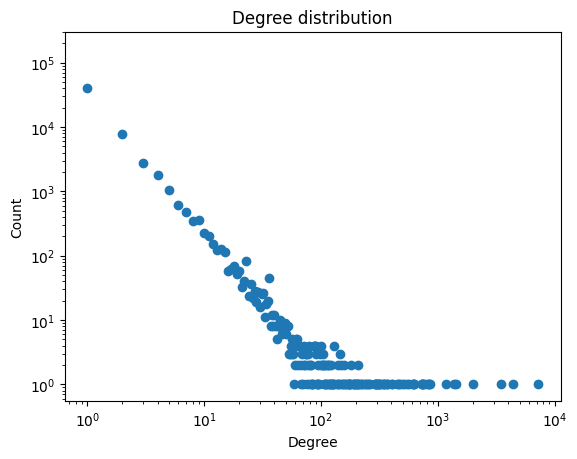

In [20]:
# basic stats
print(g.summary())
print(g.vcount())

# plot the degree distribution
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

degree = g.degree()
degree_count = Counter(degree)
degree, count = zip(*degree_count.items())

# log-log plot
plt.figure()
plt.loglog(degree, count, "o")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.title("Degree distribution")
plt.show()


In [25]:
g.degree()

[3,
 18,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 32,
 1,
 0,
 1,
 0,
 1,
 25,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 808,
 2,
 1,
 0,
 0,
 1,
 18,
 1,
 0,
 34,
 23,
 0,
 5,
 142,
 5,
 11,
 5,
 0,
 5,
 0,
 4,
 33,
 4,
 0,
 3,
 0,
 1,
 0,
 0,
 0,
 3,
 0,
 3,
 0,
 4,
 0,
 4,
 11,
 4,
 0,
 0,
 0,
 0,
 0,
 0,
 3,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 3,
 0,
 3,
 9,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 79,
 1,
 0,
 1,
 32,
 1,
 0,
 1,
 0,
 49,
 0,
 0,
 0,
 7,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 65,
 67,
 0,
 43,
 20,
 107,
 0,
 1,
 0,
 1,
 0,
 199,
 1,
 0,
 1,
 48,
 0,
 1,
 0,
 12,
 1,
 0,
 1,
 50,
 0,
 0,
 5,
 1,
 13,
 88,
 1,
 0,
 1,
 2,
 1,
 0,
 1,
 0,
 0,
 0,
 6,
 0,
 0,
 1,
 0,
 0,
 0,
 9,
 5,
 1,
 0,
 10,
 111,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,


In [27]:
degree_sequence = sorted(g.degree(), reverse=True)
import powerlaw

fit = powerlaw.Fit(degree_sequence, min_x=1)
print(fit.power_law.alpha)


Calculating best minimal value for power law fit
2.3008182839812275


Values less than or equal to 0 in data. Throwing out 0 or negative values


In [22]:
# pagerank
pagerank = g.pagerank()
# get the top 10 nodes
top_10 = np.argsort(pagerank)[-20:]
for node in top_10:
    print(id_to_username[g.vs[node]["name"]], pagerank[node])


flexghost 0.0019624691323098663
benroyce 0.0020481363492042353
thirdeyecharm 0.0021418760496617
vij 0.0022385618355139944
jon 0.002331447152517864
wikkit 0.002434250063314805
jeffjarvis 0.002442701036818613
cdarwin 0.002588804039005105
Theblueone 0.0026016861361103636
stux 0.003510025374944282
wdlindsy 0.003895041474778927
GossiTheDog 0.004489706318010461
reedmideke 0.005455851684570206
pluralistic 0.009083259489672847
dimitribouniol 0.010103673567212814
dangillmor 0.011700890342355766
GottaLaff 0.012095370165958649
thessan 0.012894038288843708
w7voa 0.015086734359308311
Nonilex 0.025232694043024098
